In [5]:
import os
import re
import math
from collections import Counter
from typing import List, Optional

import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import spacy
from sentence_transformers import SentenceTransformer
from keybert import KeyBERT


d:\Programming\nlp\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CSV_PATH = 'Reviews.csv' 
SAMPLE_SIZE = 20000 
TEXT_COLUMN = 'Text'
SEED = 42

TFIDF_MAX_FEATURES = 20000
TFIDF_NGRAM_RANGE = (1, 2)

SBERT_MODEL_NAME = 'all-mpnet-base-v2'

DBSCAN_MIN_SAMPLES = 5
DBSCAN_METRIC = 'cosine'

TOP_N_KEYWORDS = 15

In [7]:
try:
    nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser'])
except Exception as e:
    raise RuntimeError("Please install the spaCy model first: python -m spacy download en_core_web_sm")

STOP_WORDS = nlp.Defaults.stop_words

RE_EMOJI = re.compile("[\U00010000-\U0010ffff]", flags=re.UNICODE)
RE_HTML_TAGS = re.compile(r'<.*?>')
RE_NON_ALPHA = re.compile(r'[^a-zA-Z\s]')
RE_MULTI_SPACE = re.compile(r'\s+')

In [8]:
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = RE_HTML_TAGS.sub(' ', text)
    text = RE_EMOJI.sub(' ', text)
    text = text.lower()
    text = RE_NON_ALPHA.sub(' ', text)
    text = RE_MULTI_SPACE.sub(' ', text).strip()
    return text

In [9]:
def lemmatize_text(text: str, nlp_pipeline) -> str:
    doc = nlp_pipeline(text)
    lemmas = [token.lemma_ for token in doc if not (token.is_stop or token.is_punct or token.is_space)]
    return ' '.join(lemmas)

In [10]:
df = pd.read_csv(CSV_PATH, usecols=['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'])
print('Total rows in file:', len(df))

Total rows in file: 568454


In [11]:
tqdm.pandas(desc='clean')
df['text_clean'] = df[TEXT_COLUMN].progress_apply(clean_text)

clean: 100%|██████████| 568454/568454 [00:18<00:00, 30768.05it/s]


In [14]:
lemmas = []
batch_size = 10000
for i in tqdm(range(0, len(df), batch_size), desc='lemma_batches'):
    texts = df['text_clean'].iloc[i:i+batch_size].tolist()
    docs = nlp.pipe(texts, batch_size=64)
    for doc in docs:
        lemmas.append(' '.join([token.lemma_ for token in doc if not (token.is_stop or token.is_punct or token.is_space)]))


df['text_lemma'] = lemmas
print('Example (original -> lemma):')
print(df[TEXT_COLUMN].iloc[0][:200])
print(df['text_lemma'].iloc[0][:200])

lemma_batches: 100%|██████████| 57/57 [32:21<00:00, 34.07s/it]

Example (original -> lemma):
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador
buy vitality can dog food product find good quality product look like stew process meat smell well labrador finicky appreciate product well


In [20]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,text_clean,text_lemma
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,i have bought several of the vitality canned d...,buy vitality can dog food product find good qu...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled as jumbo salted peanut...,product arrive label jumbo salt peanut peanut ...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,this is a confection that has been around a fe...,confection century light pillowy citrus gelati...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,if you are looking for the secret ingredient i...,look secret ingredient robitussin believe find...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,great taffy at a great price there was a wide ...,great taffy great price wide assortment yummy ...


In [21]:
df.to_csv('cleaned_and_lemmatized_reviews.csv')

In [15]:
print('Building TF-IDF vectorizer...')
vectorizer = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, ngram_range=TFIDF_NGRAM_RANGE)
X_tfidf = vectorizer.fit_transform(df['text_lemma'].fillna(''))
print('TF-IDF shape:', X_tfidf.shape)

Building TF-IDF vectorizer...
TF-IDF shape: (568454, 20000)


In [16]:
tfidf_feature_names = np.array(vectorizer.get_feature_names_out())

In [17]:
print('Loading SBERT model:', SBERT_MODEL_NAME)
sbert = SentenceTransformer(SBERT_MODEL_NAME)

Loading SBERT model: all-mpnet-base-v2


d:\Programming\nlp\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Николай\.cache\huggingface\hub\models--sentence-transformers--all-mpnet-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [22]:
print('Computing SBERT embeddings (this may take time)...')
X_sbert = sbert.encode(df['text_lemma'].fillna('').tolist(), show_progress_bar=True, convert_to_numpy=True)
print('SBERT embeddings shape:', X_sbert.shape)

Computing SBERT embeddings (this may take time)...


Batches: 100%|██████████| 17765/17765 [34:53<00:00,  8.49it/s] 


SBERT embeddings shape: (568454, 768)


In [23]:
from sklearn.preprocessing import normalize
X_sbert_norm = normalize(X_sbert)

In [30]:
import numpy as np

SAMPLE_SIZE = 20000
RANDOM_STATE = 42

n = len(df)  # исходный размер
print(n)
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(n, size=min(SAMPLE_SIZE, n), replace=False)
print(len(sample_idx))

568454
20000


In [31]:
X_tfidf_sample = X_tfidf[sample_idx]           # если X_tfidf — scipy.sparse csr_matrix, срез вернёт sparse
X_sbert_sample = X_sbert_norm[sample_idx]      # если dense numpy array
df_sample = df.iloc[sample_idx].reset_index(drop=True)

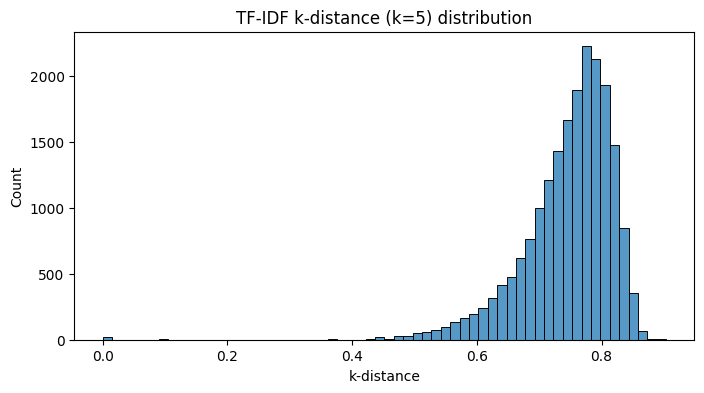

In [65]:
plt.figure(figsize=(8, 4))
sns.histplot(kdist_tfidf, bins=60)
plt.title('TF-IDF k-distance (k=%d) distribution' % DBSCAN_MIN_SAMPLES)
plt.xlabel('k-distance')
plt.show()

In [86]:
# chosen_eps_tfidf = eps_tfidf
chosen_eps_tfidf = 0.8

In [87]:
print('Fitting DBSCAN on TF-IDF...')
cl_tfidf = DBSCAN(eps=chosen_eps_tfidf, min_samples=DBSCAN_MIN_SAMPLES, metric='cosine', n_jobs=-1)
labels_tfidf = cl_tfidf.fit_predict(X_tfidf_sample)

Fitting DBSCAN on TF-IDF...


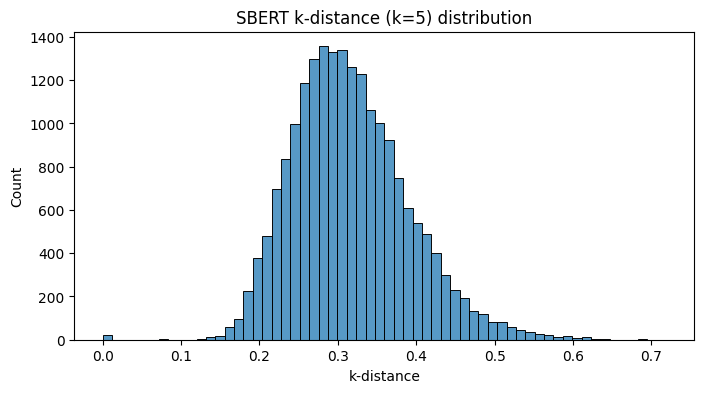

In [68]:
plt.figure(figsize=(8, 4))
sns.histplot(kdist_sbert, bins=60)
plt.title('SBERT k-distance (k=%d) distribution' % DBSCAN_MIN_SAMPLES)
plt.xlabel('k-distance')
plt.show()

In [91]:
# chosen_eps_sbert = eps_sbert
chosen_eps_sbert = 0.4

In [92]:
print('Fitting DBSCAN on SBERT vectors...')
cl_sbert = DBSCAN(eps=chosen_eps_sbert, min_samples=DBSCAN_MIN_SAMPLES, metric='cosine', n_jobs=-1)
labels_sbert = cl_sbert.fit_predict(X_sbert_sample)

Fitting DBSCAN on SBERT vectors...


In [93]:
df_sample['cluster_tfidf'] = labels_tfidf
df_sample['cluster_sbert'] = labels_sbert

In [94]:
df_sample.to_csv('labeled_reviews_sample.csv')

In [95]:
def cluster_stats(labels):
    labels = np.array(labels)
    unique, counts = np.unique(labels, return_counts=True)
    stats = dict(zip(unique.tolist(), counts.tolist()))
    n_noise = stats.get(-1, 0)
    n_clusters = len([l for l in unique if l != -1])
    return {
    'n_clusters': n_clusters,
    'n_noise': n_noise,
    'cluster_counts': stats
    }


print('\nTF-IDF clustering stats:')
print(cluster_stats(labels_tfidf))
print('\nSBERT clustering stats:')
print(cluster_stats(labels_sbert))


TF-IDF clustering stats:
{'n_clusters': 4, 'n_noise': 1083, 'cluster_counts': {-1: 1083, 0: 18906, 1: 4, 2: 5, 3: 2}}

SBERT clustering stats:
{'n_clusters': 2, 'n_noise': 1224, 'cluster_counts': {-1: 1224, 0: 18766, 1: 10}}


In [96]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
import numpy as np

metrics = {}

experiments = {
    'TF-IDF (sample)': (X_tfidf_sample, labels_tfidf),
    'SBERT (sample)':  (X_sbert_sample, labels_sbert),
}

for name, (X, labels) in experiments.items():
    labels = np.asarray(labels)

    mask = labels != -1
    labels_valid = labels[mask]

    n_samples_valid = int(mask.sum())
    n_clusters = len(np.unique(labels_valid))

    metrics[name] = {
        'n_clusters': n_clusters,
        'n_samples_used': n_samples_valid
    }

    # Для silhouette нужно минимум 2 кластера
    if n_clusters < 2 or n_samples_valid <= n_clusters:
        metrics[name].update({
            'silhouette': None,
            'calinski_harabasz': None,
            'davies_bouldin': None
        })
        continue

    if hasattr(X, 'toarray'):          # TF-IDF (sparse)
        X_valid = X[mask].toarray()
        metric = 'cosine'
    else:                              # SBERT (dense, уже нормирован)
        X_valid = X[mask]
        metric = 'cosine'

    try:
        metrics[name]['silhouette'] = float(
            silhouette_score(X_valid, labels_valid, metric=metric)
        )
        metrics[name]['calinski_harabasz'] = float(
            calinski_harabasz_score(X_valid, labels_valid)
        )
        metrics[name]['davies_bouldin'] = float(
            davies_bouldin_score(X_valid, labels_valid)
        )
    except Exception as e:
        metrics[name]['error'] = str(e)

print('\nClustering quality metrics (sampled data):')
for k, v in metrics.items():
    print(k, v)


Clustering quality metrics (sampled data):
TF-IDF (sample) {'n_clusters': 4, 'n_samples_used': 18917, 'silhouette': -0.004578703487626247, 'calinski_harabasz': 1.9580420437195356, 'davies_bouldin': 2.39352993283867}
SBERT (sample) {'n_clusters': 2, 'n_samples_used': 18776, 'silhouette': 0.18195809423923492, 'calinski_harabasz': 9.258071899414062, 'davies_bouldin': 1.7839152153346591}


In [97]:
print('\nTop TF-IDF terms per cluster (TF-IDF, sampled data)')

def top_tfidf_terms_per_cluster_sample(
    X_tfidf,
    labels,
    feature_names,
    top_n=TOP_N_KEYWORDS
):
    labels = np.asarray(labels)
    clusters = np.unique(labels)
    clusters = clusters[clusters != -1]  # убираем шум

    top_terms = {}

    for c in clusters:
        idx = np.where(labels == c)[0]
        if idx.size == 0:
            top_terms[c] = []
            continue

        # Средний TF-IDF вектор по кластеру
        # Для sparse csr_matrix mean(axis=0) работает корректно
        cluster_mean = X_tfidf[idx].mean(axis=0)

        # Приводим к 1D numpy array
        cluster_mean = np.asarray(cluster_mean).ravel()

        top_idx = np.argsort(cluster_mean)[::-1][:top_n]
        top_terms[c] = feature_names[top_idx].tolist()

    return top_terms


cluster_top_terms_tfidf_sample = top_tfidf_terms_per_cluster_sample(
    X_tfidf_sample,
    labels_tfidf,
    tfidf_feature_names,
    TOP_N_KEYWORDS
)

for c, words in cluster_top_terms_tfidf_sample.items():
    print(f'Cluster {c}: {words[:10]}')



Top TF-IDF terms per cluster (TF-IDF, sampled data)
Cluster 0: ['good', 'like', 'taste', 'coffee', 'love', 'flavor', 'great', 'product', 'tea', 'buy']
Cluster 1: ['desk work', 'desk', 'work', 'tastey', 'work ve', 'lunch', 'oyster', 'munch', 've eat', 'buy pound']
Cluster 2: ['crunchie', 'brand dry', 'dry fruit', 'type', 'fruit', 'brand', 'cereal morning', 'plan buy', 'dry', 'buy pack']
Cluster 3: ['headache', 'prescription', 'suffer', 'vinegar', 'time end', 'try instead', 'able', 'single pack', 'good night', 'stuff use']


In [100]:
from keybert import KeyBERT
from tqdm import tqdm
import numpy as np

print('\nExtracting keywords with KeyBERT (SBERT, sampled data)')

kw_model = KeyBERT(model=sbert)   # sbert — ваш SentenceTransformer

cluster_top_terms_sbert_sample = {}
labels = np.asarray(labels_sbert)   # <- убедитесь, что это именно метки для df_sample

# Ограничение по числу документов в одном кластере при объединении
max_docs_for_kw = 500
TOP_N_KEYWORDS = 15

for c in np.unique(labels):
    if c == -1:
        continue  # шум

    idx = np.where(labels == c)[0]
    if idx.size == 0:
        cluster_top_terms_sbert_sample[c] = []
        continue

    # Берём лемматизированные тексты именно из сэмпла
    docs = df_sample.loc[idx, 'text_lemma'].dropna().astype(str).tolist()
    if len(docs) == 0:
        cluster_top_terms_sbert_sample[c] = []
        continue

    # Ограничиваем число документов для скорости (если кластер огромный)
    docs_to_use = docs if len(docs) <= max_docs_for_kw else docs[:max_docs_for_kw]

    # Объединяем документы в один большой документ — классический подход для cluster-level keywords
    combined_doc = ' '.join(docs_to_use)

    try:
        keywords = kw_model.extract_keywords(
            combined_doc,
            keyphrase_ngram_range=(1, 2),
            stop_words='english',   # либо None; строка 'english' убирает предупреждение sklearn
            top_n=TOP_N_KEYWORDS,
            use_mmr=True,
            diversity=0.7
        )
        # keywords — список кортежей (keyword, score)
        cluster_top_terms_sbert_sample[c] = [kw for kw, score in keywords]
    except Exception as e:
        print(f'KeyBERT failed for cluster {c}: {e}')
        cluster_top_terms_sbert_sample[c] = []

# Печать результатов
for c, words in cluster_top_terms_sbert_sample.items():
    print(f'Cluster {c}: {words[:10]}')


Extracting keywords with KeyBERT (SBERT, sampled data)
Cluster 0: ['review recipe', 'easy read', 'paper desk', 'sort purchase', 'veggie year', 'recommendation start', 'increase behavior', 'know fine', 'structured bean', 'alternative rawhide']
Cluster 1: ['burton beetlejuice', 'dvd lack', 'story purposely', 'studio stamp', 'help guide', 'enjoy far', 'agree people', 'result mixture', 'brainer upgrade', 'beuracratic world']


In [ ]:
from wordcloud import WordCloud

In [101]:
OUT_DIR = './clustering_output'
WC_DIR = os.path.join(OUT_DIR, 'wordclouds')
os.makedirs(WC_DIR, exist_ok=True)

# Параметры визуализации wordcloud
WC_WIDTH = 900
WC_HEIGHT = 500
WC_MAX_WORDS = 200
WC_BG = 'white'
WC_COLORMAP = 'viridis'   # можно заменить на 'tab10', 'plasma', 'cividis' и т.д.

# Утилитарная функция: строит частотный словарь для кластера из лемматизированных текстов
def cluster_token_frequencies(text_series, labels, cluster_label, stop_words=STOP_WORDS, min_token_len=2):
    """
    text_series: pd.Series of lemmatized texts (aligned with labels)
    labels: numpy array of labels aligned with text_series
    cluster_label: int
    returns Counter of tokens (strings)
    """
    mask = (labels == cluster_label)
    texts = text_series[mask].dropna().astype(str).tolist()
    if len(texts) == 0:
        return Counter()
    tokens = []
    for doc in texts:
        for t in doc.split():
            t = t.strip()
            if not t:
                continue
            if t in stop_words:
                continue
            if len(t) < min_token_len:
                continue
            tokens.append(t)
    return Counter(tokens)

# Функция - генерация WordCloud от Counter
def make_wordcloud_from_counter(counter, width=WC_WIDTH, height=WC_HEIGHT, max_words=WC_MAX_WORDS,
                                background_color=WC_BG, colormap=WC_COLORMAP):
    if not counter:
        return None
    wc = WordCloud(
        width=width,
        height=height,
        max_words=max_words,
        background_color=background_color,
        colormap=colormap,
        collocations=False
    ).generate_from_frequencies(counter)
    return wc

# Функция отрисовки сетки wordcloud'ов и сохранения файлов
def plot_and_save_wordclouds(labels_arr, texts_series, method_name='method', top_n_clusters=6):
    counts = Counter(labels_arr)
    counts.pop(-1, None)  # исключаем шум
    if not counts:
        print(f'No clusters to plot for {method_name}.')
        return

    top_clusters = [c for c, _ in counts.most_common(top_n_clusters)]
    n = len(top_clusters)
    n_rows = math.ceil(n / 2)
    fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5 * n_rows))
    axes = axes.flatten()

    for i, c in enumerate(top_clusters):
        counter = cluster_token_frequencies(texts_series, labels_arr, c)
        wc = make_wordcloud_from_counter(counter)
        if wc is None:
            axes[i].text(0.5, 0.5, 'No data', horizontalalignment='center', verticalalignment='center')
            axes[i].axis('off')
            continue

        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].axis('off')
        axes[i].set_title(f'{method_name} — Cluster {c} (size={counts[c]})', fontsize=12)

        # Сохраняем отдельный файл для кластера
        out_path = os.path.join(WC_DIR, f'{method_name}_cluster_{c}.png')
        wc.to_file(out_path)

    # Скрываем лишние оси
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

TF-IDF cluster wordclouds (sample):


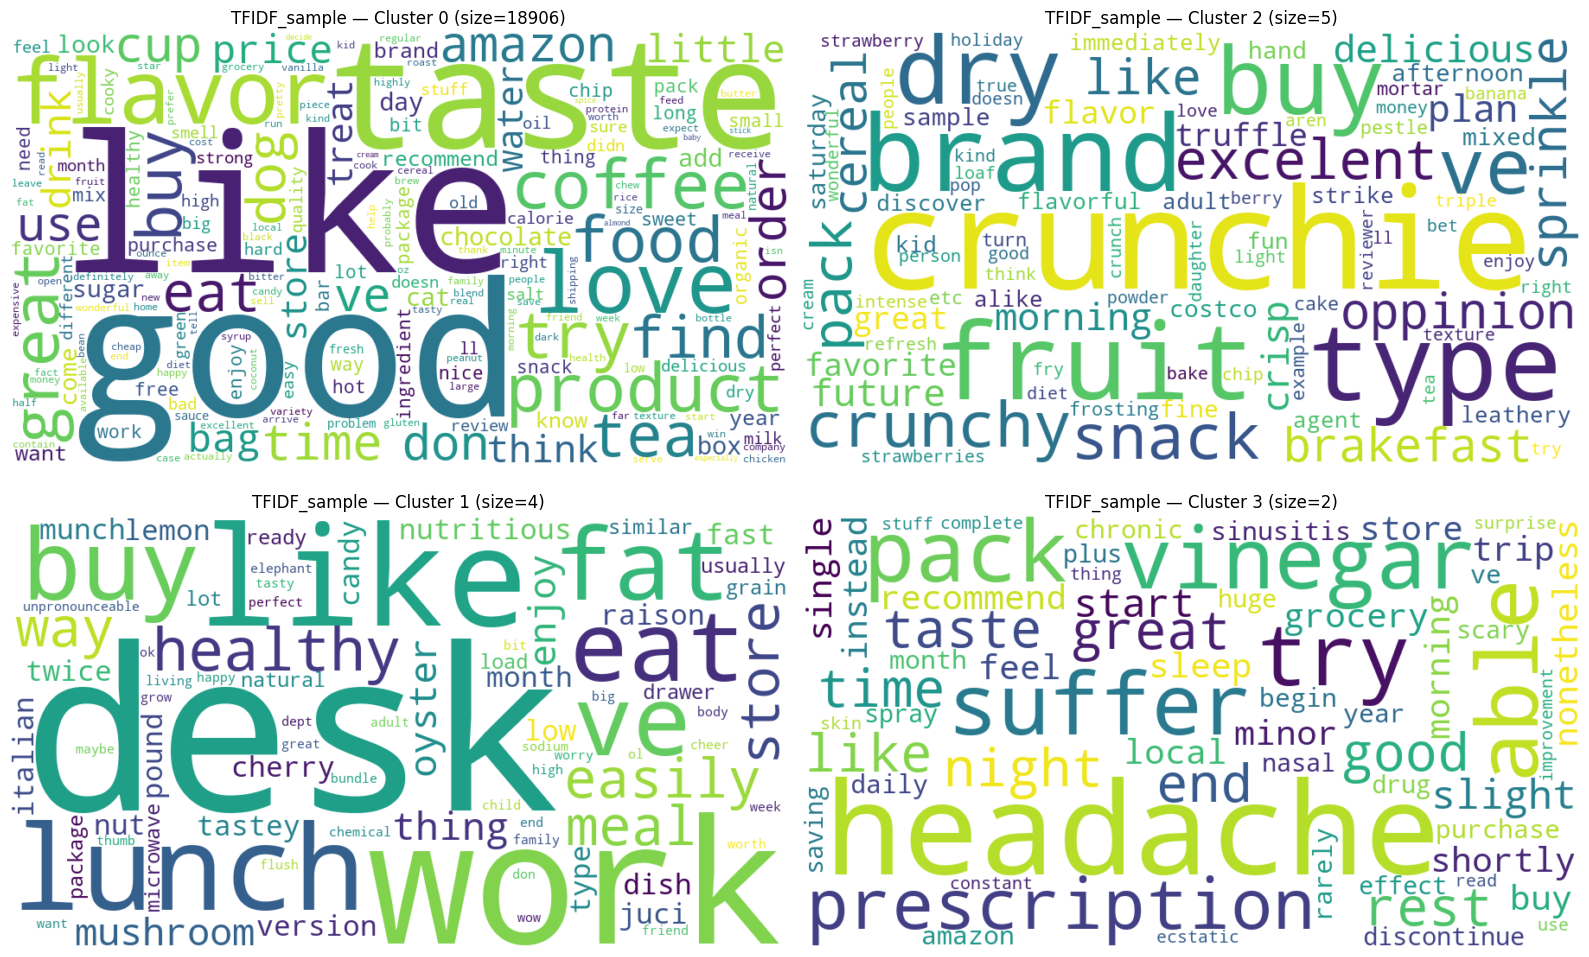

In [102]:
# Вызов для TF-IDF (sample)
print('TF-IDF cluster wordclouds (sample):')
plot_and_save_wordclouds(
    labels_arr = np.asarray(labels_tfidf),
    texts_series = df_sample['text_lemma'],
    method_name = 'TFIDF_sample',
    top_n_clusters = 6
)

SBERT cluster wordclouds (sample):


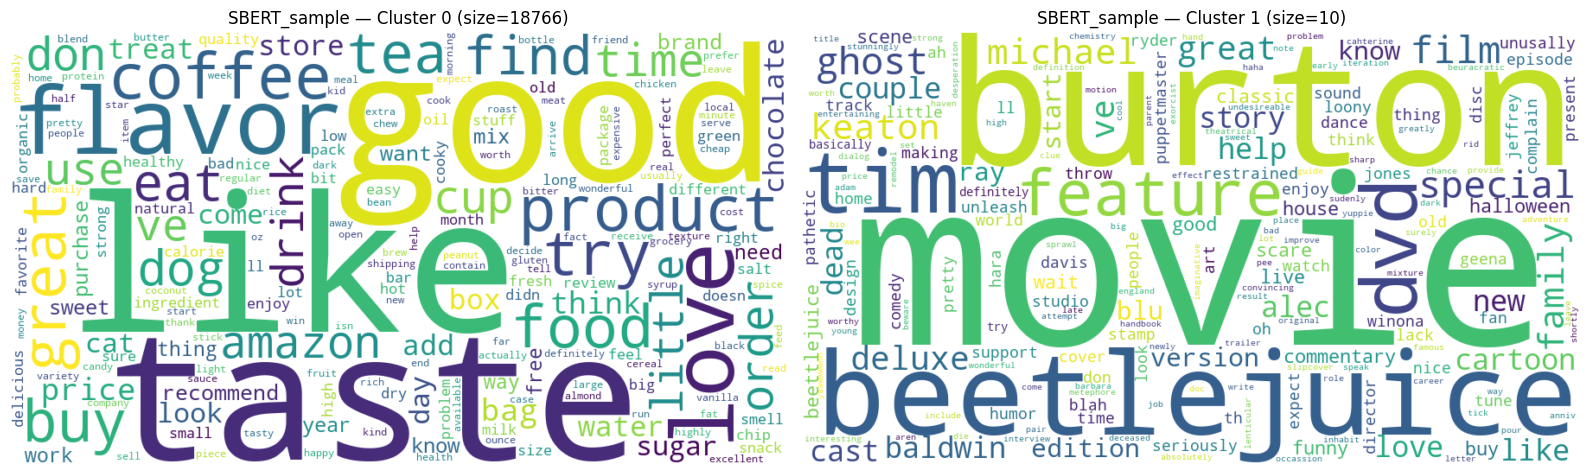

In [103]:
print('SBERT cluster wordclouds (sample):')
plot_and_save_wordclouds(
    labels_arr = np.asarray(labels_sbert),
    texts_series = df_sample['text_lemma'],
    method_name = 'SBERT_sample',
    top_n_clusters = 6
)

In [104]:
summary_rows = []

# TF-IDF (sample)
tfidf_counts = Counter(np.asarray(labels_tfidf))
for c, count in sorted(tfidf_counts.items(), key=lambda x: (-x[1], x[0])):
    if c == -1:
        continue
    top_terms = cluster_top_terms_tfidf_sample.get(c, []) if 'cluster_top_terms_tfidf_sample' in globals() else []
    # Возьмём также несколько примеров текстов из кластера (максимум 3, чтобы не засорять таблицу)
    idx = np.where(np.asarray(labels_tfidf) == c)[0]
    examples = df_sample.loc[idx, 'text_lemma'].dropna().astype(str).tolist()[:3]
    summary_rows.append({
        'method': 'tfidf',
        'cluster': int(c),
        'size': int(count),
        'top_terms': ', '.join(top_terms[:10]),
        'examples': ' || '.join(examples)
    })

# SBERT (sample)
sbert_counts = Counter(np.asarray(labels_sbert))
for c, count in sorted(sbert_counts.items(), key=lambda x: (-x[1], x[0])):
    if c == -1:
        continue
    top_terms = cluster_top_terms_sbert_sample.get(c, []) if 'cluster_top_terms_sbert_sample' in globals() else []
    idx = np.where(np.asarray(labels_sbert) == c)[0]
    examples = df_sample.loc[idx, 'text_lemma'].dropna().astype(str).tolist()[:3]
    summary_rows.append({
        'method': 'sbert',
        'cluster': int(c),
        'size': int(count),
        'top_terms': ', '.join(top_terms[:10]),
        'examples': ' || '.join(examples)
    })

# Создаём DataFrame
summary_df = pd.DataFrame(summary_rows)

# Сортируем и выводим топ-20 строк
print('Cluster summary (sample):')
display(summary_df.sort_values(['method', 'size'], ascending=[True, False]).head(20))

# Сохраняем результаты: df_sample с метками, summary_df и топ-слова
os.makedirs(OUT_DIR, exist_ok=True)

summary_df.to_csv(os.path.join(OUT_DIR, 'clusters_summary_sample.csv'), index=False)

print(f'\nOutputs saved to {OUT_DIR}:')
print(' - reviews_sample_with_clusters.csv')
print(' - clusters_summary_sample.csv')
print(f' - wordcloud images in {WC_DIR}')

Cluster summary (sample):


,method,cluster,size,top_terms,examples
4,sbert,0,18766,"review recipe, easy read, paper desk, sort pur...",agree review product dry cranberry excellent e...
5,sbert,1,10,"burton beetlejuice, dvd lack, story purposely,...",ah tim burton start take seriously michael kea...
0,tfidf,0,18906,"good, like, taste, coffee, love, flavor, great...",oatmeal bland tasting taste little vanilla fla...
1,tfidf,2,5,"crunchie, brand dry, dry fruit, type, fruit, b...",ve buy pack type crunchie brand dry fruit exce...
2,tfidf,1,4,"desk work, desk, work, tastey, work ve, lunch,...",nut desk work tastey nutritious munch raison f...
3,tfidf,3,2,"headache, prescription, suffer, vinegar, time ...",try like taste great good night rest time end ...



Outputs saved to ./clustering_output:
 - reviews_sample_with_clusters.csv
 - clusters_summary_sample.csv
 - wordcloud images in ./clustering_output\wordclouds
